<a href="https://colab.research.google.com/github/troubleeee66/loose-expedition/blob/main/pyswmm_flooding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pyswmm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 520.8/520.8 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 13.6 MB/s eta 0:00:00
  Created wheel for julian: filename=julian-0.14-py3-none-any.whl size=2613 sha256=03d129a285f965eb4634f1fdfc7ce110ce65ec3b540e75123d9c173900e0faf9
  Stored in directory: /root/.cache/pip/wheels/6b/8b/6f/f2610e040b0950d56996c5bfb542e53dbf58e0d99b2a14814c
Successfully built julian


In [3]:
!pip install pyswmm swmm-toolkit -q

In [4]:
import re

src_path = "/content/Astlingen_SWMM.inp"
dst_path = "/content/Astlingen_SWMM_colab.inp"

with open(src_path, "r", encoding="utf-8", errors="ignore") as f:
    content = f.read()

# 윈도우 절대경로 -> Colab 경로로 치환
replacements = {
    r'C:\scc\scc\posdoc\DTU\closed-loop Astlingen\20190813\rainfall\1Astlingen_Erft1.txt': '/content/1Astlingen_Erft1.txt',
    r'C:\scc\scc\posdoc\DTU\closed-loop Astlingen\20190813\rainfall\2Astlingen_Erft2.txt': '/content/2Astlingen_Erft2.txt',
    r'C:\scc\scc\posdoc\DTU\closed-loop Astlingen\20190813\rainfall\3Astlingen_Erft3.txt': '/content/3Astlingen_Erft3.txt',
    r'C:\scc\scc\posdoc\DTU\closed-loop Astlingen\20190813\rainfall\4Astlingen_Erft4.txt': '/content/4Astlingen_Erft4.txt',
    r'C:\scc\scc\posdoc\DTU\closed-loop Astlingen\20190813\astingen.jpg': '/content/astingen.jpg',
}

for old, new in replacements.items():
    content = content.replace(old, new)

with open(dst_path, "w", encoding="utf-8") as f:
    f.write(content)

print("경로 치환 완료 ->", dst_path)

경로 치환 완료 -> /content/Astlingen_SWMM_colab.inp


In [5]:
from pyswmm import Simulation, Nodes, Links

inp_file = dst_path  # 또는 efd_inp_path (EFD로 돌리려면)

with Simulation(inp_file) as sim:
    T2 = Nodes(sim)["T2"]
    T3 = Nodes(sim)["T3"]
    T4 = Nodes(sim)["T4"]
    T6 = Nodes(sim)["T6"]
    V2 = Links(sim)["V2"]

    results = []
    for step in sim:
        results.append({
            "time": sim.current_time,
            "T2_depth": T2.depth,
            "T3_depth": T3.depth,
            "T4_depth": T4.depth,
            "T6_depth": T6.depth,
            "V2_setting": V2.current_setting,
        })

    print("시뮬레이션 완료. 총 스텝:", len(results))

시뮬레이션 완료. 총 스텝: 1065320


In [6]:
import plotly.graph_objects as go
tanks = ["T2_depth", "T3_depth", "T4_depth", "T6_depth"]

fig = go.Figure()
for col, c in zip(tanks, ["blue", "orange", "green", "red"]):
    fig.add_trace(go.Scatter(x=df.index, y=df[col], mode="lines", name=col, line=dict(width=1, color=c)))

fig.update_layout(
    title="Tank depths over simulation (interactive)",
    xaxis_title="time",
    yaxis_title="Depth (m)",
    height=500,
    hovermode="x unified"
)
fig.update_xaxes(rangeslider_visible=True)  # 하단에 슬라이더로 구간 선택 가능
fig.show()

NameError: name 'df' is not defined

In [7]:
!pip install swmm-api -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 6.3 MB/s eta 0:00:00


NameError: name 'conduits' is not defined

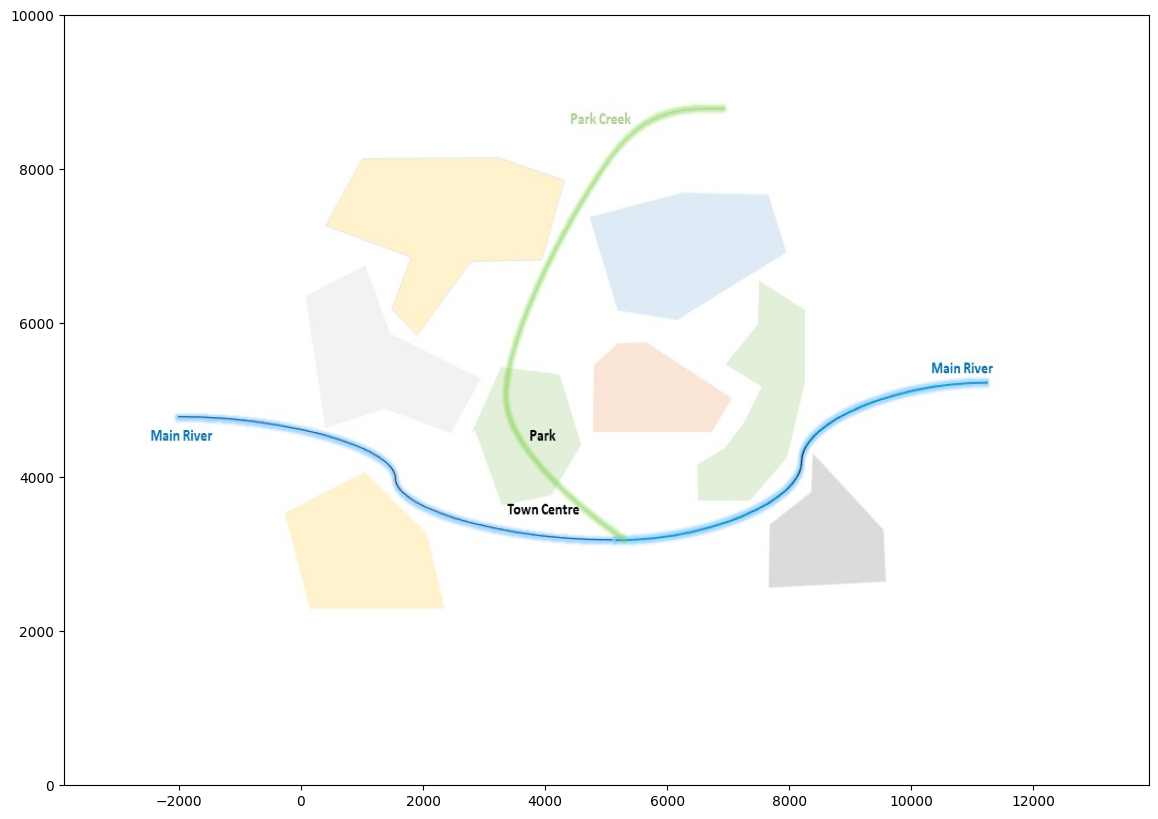

In [8]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.lines import Line2D
from matplotlib.patches import Circle

img = mpimg.imread("/content/astingen.jpg")
extent = (-3888.889, 13888.889, 0.000, 10000.000)

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(img, extent=extent, aspect="auto", zorder=0)

# Existing links (pipes)
for name, n1, n2 in conduits + orifices:
    if n1 in coords and n2 in coords:
        x1, y1 = coords[n1]
        x2, y2 = coords[n2]
        ax.plot([x1, x2], [y1, y2], color="pink", linewidth=3, zorder=1, alpha=0.8)

# --- Full path: T3 -> V3(orifice) -> J14 -> C3(clogged) -> J3 ---
path_nodes = ["T3", "J14", "J3"]
for i in range(len(path_nodes) - 1):
    n1, n2 = path_nodes[i], path_nodes[i+1]
    if n1 in coords and n2 in coords:
        x1, y1 = coords[n1]
        x2, y2 = coords[n2]
        ax.plot([x1, x2], [y1, y2], color="red", linewidth=3, zorder=4, alpha=0.9)

# --- Nodes / tanks ---
tank_names = {"T1","T2","T3","T4","T5","T6"}
for name, (x, y) in coords.items():
    if name in tank_names:
        ax.scatter(x, y, s=200, color="cyan", edgecolor="black", zorder=3)
        ax.annotate(name, (x, y), fontsize=10, fontweight="bold", color="black",
                    xytext=(6,6), textcoords="offset points")
    else:
        ax.scatter(x, y, s=15, color="black", zorder=5, alpha=0.7)

# --- Clog point (BLK_C3) ---
blk_x = (coords["J14"][0] + coords["J3"][0]) / 2
blk_y = (coords["J14"][1] + coords["J3"][1]) / 2

ax.scatter(blk_x, blk_y, s=120, color="orange", edgecolor="darkred", linewidth=1.5,
           marker="X", zorder=5)

# 텍스트를 위쪽 빈 공간(Park Creek 우측 빈 영역)으로 이동 + 화이트 배경 박스 추가
ax.annotate("Clog point (BLK_C3)\nshort segment J14→J3", (blk_x, blk_y),
            fontsize=9, fontweight="bold", color="darkred",
            xytext=(blk_x + 1800, blk_y + 2200), textcoords="data", ha="left", va="bottom",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="darkred", alpha=0.9))

# Legend - 우측 상단으로 이동 (하단은 비어있지만 위가 더 안전)
legend_elements = [
    Line2D([0], [0], color="red", linewidth=3, label="Flow path T3 → V3 → J14 → C3 (clogged) → J3"),
    Line2D([0], [0], marker="X", color="w", markerfacecolor="orange",
           markeredgecolor="darkred", markersize=12, label="Clog point manhole (BLK_C3)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="cyan",
           markeredgecolor="black", markersize=10, label="Tanks (T1-T6)"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=9, framealpha=0.9)

ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.set_title("Clogged Conduit (C3) and Manhole Location")
ax.axis("off")
plt.tight_layout()
plt.show()

# 1단계 — 막힘 구조 생성

In [9]:
from swmm_api import SwmmInput
from swmm_api.input_file.sections import Junction, Conduit, Coordinate, CrossSection

inp = SwmmInput.read_file("/content/Astlingen_SWMM_colab.inp")

TARGET_CONDUIT = "C3"   # T3 탱크 출구 관로 (J14 -> J3)
orig = inp.CONDUITS[TARGET_CONDUIT]
from_node, to_node = orig.from_node, orig.to_node
orig_xsect = inp.XSECTIONS[TARGET_CONDUIT]

# 가상 노드(막힘 직전 지점) 추가
to_node_elev = inp.JUNCTIONS[to_node].elevation if to_node in inp.JUNCTIONS else 20.0
blk_node_name = f"BLK_{TARGET_CONDUIT}"
inp.JUNCTIONS[blk_node_name] = Junction(
    name=blk_node_name, elevation=to_node_elev,
    depth_max=10, depth_init=0, depth_surcharge=0, area_ponded=0
)

# 원래 관을 절반으로 나눠서 from_node->BLK, BLK->to_node 구조로
half_len = orig.length / 2
inp.CONDUITS[TARGET_CONDUIT] = Conduit(
    name=TARGET_CONDUIT, from_node=from_node, to_node=blk_node_name,
    length=half_len, roughness=orig.roughness,
    offset_upstream=orig.offset_upstream, offset_downstream=0,
    flow_initial=orig.flow_initial, flow_max=orig.flow_max
)

CLOG_LINK = f"CLOG_{TARGET_CONDUIT}"
inp.CONDUITS[CLOG_LINK] = Conduit(
    name=CLOG_LINK, from_node=blk_node_name, to_node=to_node,
    length=half_len, roughness=orig.roughness,
    offset_upstream=0, offset_downstream=orig.offset_downstream,
    flow_initial=0, flow_max=orig.flow_max
)

inp.XSECTIONS[TARGET_CONDUIT] = orig_xsect
inp.XSECTIONS[CLOG_LINK] = CrossSection(
    link=CLOG_LINK, shape=orig_xsect.shape, height=orig_xsect.height,
    parameter_2=orig_xsect.parameter_2, parameter_3=orig_xsect.parameter_3,
    parameter_4=orig_xsect.parameter_4, n_barrels=orig_xsect.n_barrels
)

from_xy = inp.COORDINATES[from_node]
to_xy = inp.COORDINATES[to_node]
inp.COORDINATES[blk_node_name] = Coordinate(
    blk_node_name, (from_xy.x + to_xy.x) / 2, (from_xy.y + to_xy.y) / 2
)

inp.write_file("/content/Astlingen_SWMM_blocked_C3.inp")
print("막힘 시나리오 base inp 생성 완료")

막힘 시나리오 base inp 생성 완료


# 2단계 — 막힘률별 시나리오 실행

In [10]:
from pyswmm import Simulation, Nodes, Links
import re
import pandas as pd

def make_scenario(blockage_pct, base_inp="/content/Astlingen_SWMM_blocked_C3.inp",
                   start="01/03/2000", end="01/06/2000"):
    inp_b = SwmmInput.read_file(base_inp)
    orig_height = inp_b.XSECTIONS["CLOG_C3"].height
    # 면적 기준 축소 -> 원형관 지름으로 환산 (area ∝ d^2)
    reduction_factor = (1 - blockage_pct / 100) ** 0.5
    new_height = max(orig_height * reduction_factor, 0.03)  # 완전 폐색 방지
    inp_b.XSECTIONS["CLOG_C3"].height = new_height

    path = f"/content/_scn_C3_{blockage_pct}.inp"
    inp_b.write_file(path)

    with open(path, "r", encoding="utf-8") as f:
        content = f.read()
    content = re.sub(r"START_DATE\s+\S+", f"START_DATE          {start}", content)
    content = re.sub(r"END_DATE\s+\S+", f"END_DATE            {end}", content)
    with open(path, "w", encoding="utf-8") as f:
        f.write(content)
    return path

BLOCKAGE_LEVELS = [0, 30, 60, 80, 90, 95]
results = {}

for pct in BLOCKAGE_LEVELS:
    path = make_scenario(pct)
    records = []
    with Simulation(path) as sim:
        t3 = Nodes(sim)["T3"]
        blk = Nodes(sim)["BLK_C3"]      # 막힘 직전 지점 - 핵심 관찰 변수
        clog = Links(sim)["CLOG_C3"]    # 막힌 관 자체
        for step in sim:
            records.append({
                "time": sim.current_time,
                "T3_depth": t3.depth,
                "BLK_depth": blk.depth,       # 막힘으로 인한 수위 상승
                "BLK_flooding": blk.flooding, # 침수 발생 시 여기에 값이 찍힘
                "clog_flow": clog.flow,       # 막힌 관 통과 유량
            })
    results[pct] = pd.DataFrame(records).set_index("time")
    print(f"{pct}% 막힘 완료 - BLK 최대수위: {results[pct]['BLK_depth'].max():.3f}m")

0% 막힘 완료 - BLK 최대수위: 0.274m
30% 막힘 완료 - BLK 최대수위: 0.281m
60% 막힘 완료 - BLK 최대수위: 0.305m


KeyboardInterrupt: 

# 3단계 — 결과 시각화

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
colors = plt.cm.Reds([0.3, 0.45, 0.6, 0.75, 0.9, 1.0])

for (pct, df), c in zip(results.items(), colors):
    axes[0].plot(df.index, df["BLK_depth"], label=f"{pct}% blocked", color=c)
    axes[1].plot(df.index, df["clog_flow"], label=f"{pct}% blocked", color=c)
    axes[2].plot(df.index, df["T3_depth"], label=f"{pct}% blocked", color=c)

axes[0].set_ylabel("Depth just upstream\nof clog (m)")
axes[0].set_title("Water level immediately upstream of clogged pipe (C3)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_ylabel("Flow through\nclogged pipe (CMS)")
axes[1].set_title("Discharge through clogged section")
axes[1].grid(alpha=0.3)

axes[2].set_ylabel("T3 Tank depth (m)")
axes[2].set_title("Upstream tank (T3) depth — buffered by orifice V3")
axes[2].set_xlabel("time")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 1단계 — 막힘 구조 생성 (C3 관로, depth_max=1.5m 현실화)

In [11]:
from swmm_api import SwmmInput
from swmm_api.input_file.sections import Junction, Conduit, Coordinate, CrossSection

inp = SwmmInput.read_file("/content/Astlingen_SWMM_colab.inp")

TARGET_CONDUIT = "C3"
orig = inp.CONDUITS[TARGET_CONDUIT]
from_node, to_node = orig.from_node, orig.to_node
orig_xsect = inp.XSECTIONS[TARGET_CONDUIT]

to_node_elev = inp.JUNCTIONS[to_node].elevation if to_node in inp.JUNCTIONS else 20.0
blk_node_name = f"BLK_{TARGET_CONDUIT}"

REALISTIC_SURFACE_DEPTH = 1.5  # 지표면까지 여유 깊이 (m)
inp.JUNCTIONS[blk_node_name] = Junction(
    name=blk_node_name, elevation=to_node_elev,
    depth_max=REALISTIC_SURFACE_DEPTH, depth_init=0, depth_surcharge=0, area_ponded=0
)

half_len = orig.length / 2
inp.CONDUITS[TARGET_CONDUIT] = Conduit(
    name=TARGET_CONDUIT, from_node=from_node, to_node=blk_node_name,
    length=half_len, roughness=orig.roughness,
    offset_upstream=orig.offset_upstream, offset_downstream=0,
    flow_initial=orig.flow_initial, flow_max=orig.flow_max
)

CLOG_LINK = f"CLOG_{TARGET_CONDUIT}"
inp.CONDUITS[CLOG_LINK] = Conduit(
    name=CLOG_LINK, from_node=blk_node_name, to_node=to_node,
    length=half_len, roughness=orig.roughness,
    offset_upstream=0, offset_downstream=orig.offset_downstream,
    flow_initial=0, flow_max=orig.flow_max
)

inp.XSECTIONS[TARGET_CONDUIT] = orig_xsect
inp.XSECTIONS[CLOG_LINK] = CrossSection(
    link=CLOG_LINK, shape=orig_xsect.shape, height=orig_xsect.height,
    parameter_2=orig_xsect.parameter_2, parameter_3=orig_xsect.parameter_3,
    parameter_4=orig_xsect.parameter_4, n_barrels=orig_xsect.n_barrels
)

from_xy = inp.COORDINATES[from_node]
to_xy = inp.COORDINATES[to_node]
inp.COORDINATES[blk_node_name] = Coordinate(
    blk_node_name, (from_xy.x + to_xy.x) / 2, (from_xy.y + to_xy.y) / 2
)

inp.write_file("/content/Astlingen_SWMM_blocked_C3_flood.inp")
print(f"저장 완료. BLK_C3 depth_max = {REALISTIC_SURFACE_DEPTH}m")

저장 완료. BLK_C3 depth_max = 1.5m


In [12]:
from pyswmm import Simulation, Nodes, Links
import re
import pandas as pd

def make_scenario(blockage_pct, base_inp="/content/Astlingen_SWMM_blocked_C3_flood.inp",
                   start="01/03/2000", end="01/06/2000"):
    inp_b = SwmmInput.read_file(base_inp)
    orig_height = inp_b.XSECTIONS["CLOG_C3"].height
    reduction_factor = (1 - blockage_pct / 100) ** 0.5
    new_height = max(orig_height * reduction_factor, 0.03)
    inp_b.XSECTIONS["CLOG_C3"].height = new_height

    path = f"/content/_scnflood_C3_{blockage_pct}.inp"
    inp_b.write_file(path)

    with open(path, "r", encoding="utf-8") as f:
        content = f.read()
    content = re.sub(r"START_DATE\s+\S+", f"START_DATE          {start}", content)
    content = re.sub(r"END_DATE\s+\S+", f"END_DATE            {end}", content)
    with open(path, "w", encoding="utf-8") as f:
        f.write(content)
    return path

BLOCKAGE_LEVELS = [0, 85, 90, 91, 92, 93, 94, 95]
results = {}

for pct in BLOCKAGE_LEVELS:
    path = make_scenario(pct)
    records = []
    with Simulation(path) as sim:
        t3 = Nodes(sim)["T3"]
        blk = Nodes(sim)["BLK_C3"]
        clog = Links(sim)["CLOG_C3"]
        for step in sim:
            records.append({
                "time": sim.current_time,
                "T3_depth": t3.depth,
                "BLK_depth": blk.depth,
                "BLK_flooding": blk.flooding,
                "clog_flow": clog.flow,
            })
    results[pct] = pd.DataFrame(records).set_index("time")
    print(f"{pct}% 완료")

0% 완료
85% 완료
90% 완료
91% 완료
92% 완료
93% 완료
94% 완료
95% 완료


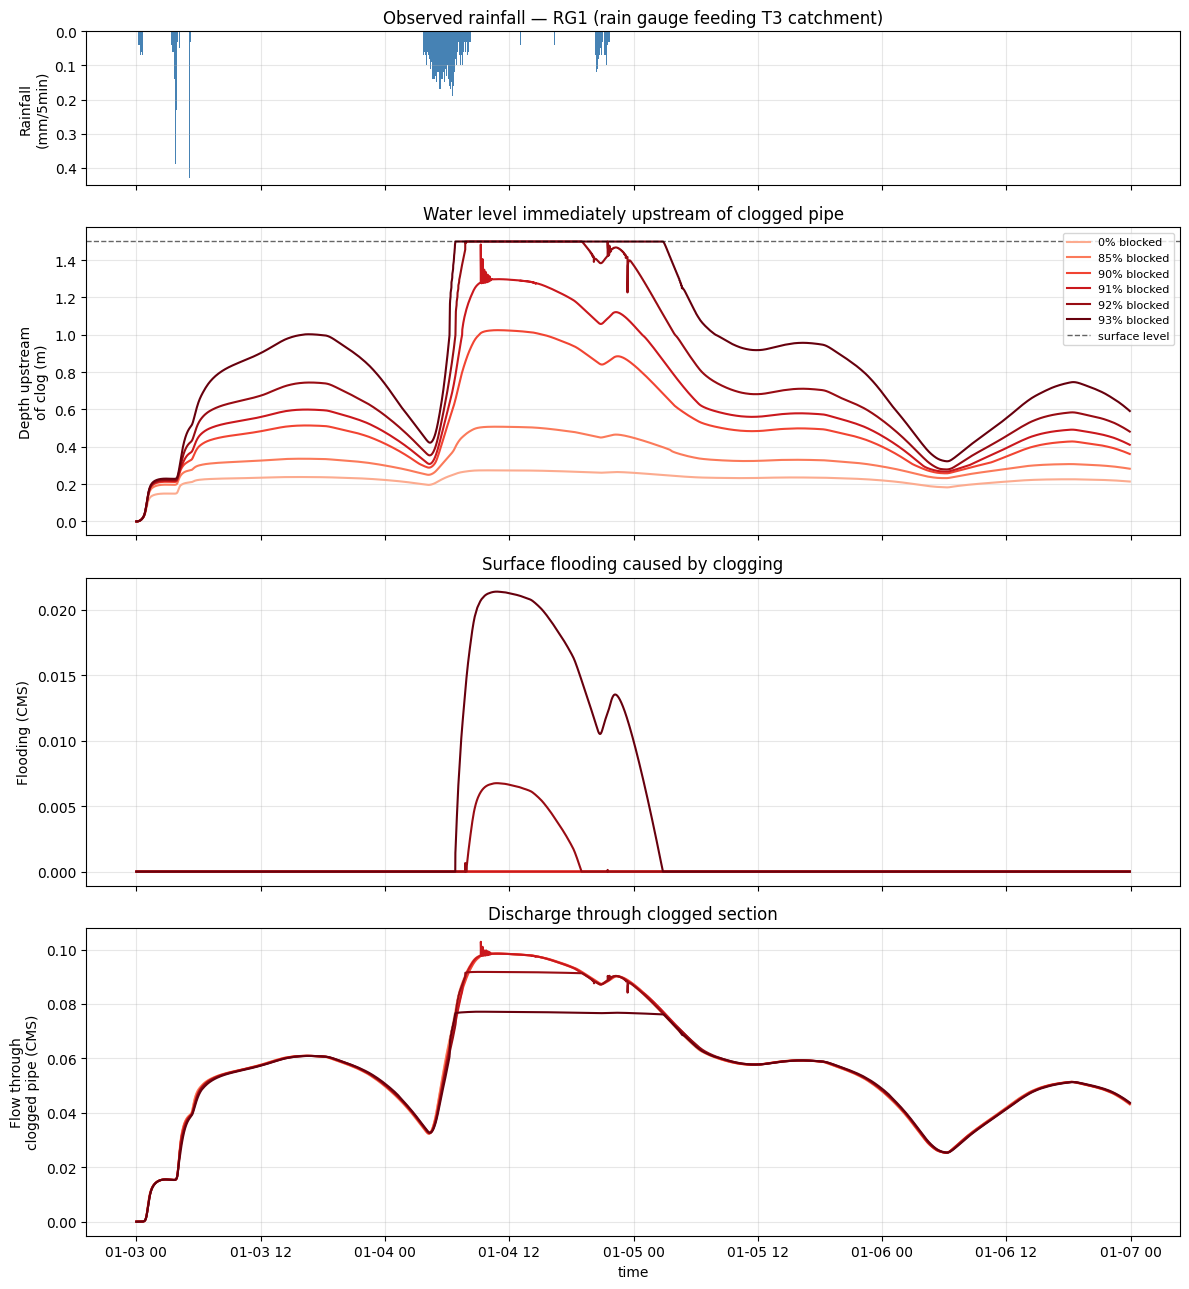

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# --- RG1 강우 데이터 로드 (T3와 가장 직접 연결된 강우계) ---
rain_df = pd.read_csv(
    "/content/1Astlingen_Erft1.txt",
    sep=r"\s+", header=None,
    names=["date", "time", "rainfall_mm"]
)
rain_df["datetime"] = pd.to_datetime(rain_df["date"] + " " + rain_df["time"], format="%m/%d/%Y %H:%M:%S")
rain_df = rain_df.set_index("datetime")

# 시뮬레이션 기간과 동일하게 자르기
PLOT_START = "2000-01-03"
PLOT_END = "2000-01-06"
rain_window = rain_df.loc[PLOT_START:PLOT_END, "rainfall_mm"]

# --- 4패널 그래프: 강우 + 기존 3개 ---
fig, axes = plt.subplots(4, 1, figsize=(12, 13), sharex=True,
                          gridspec_kw={"height_ratios": [1, 2, 2, 2]})
colors = plt.cm.Reds([0.3, 0.45, 0.6, 0.75, 0.9, 1.0])

# Panel 0: Rainfall (bar chart, y축 뒤집어서 강우 그래프 관례 따름)
axes[0].bar(rain_window.index, rain_window.values, width=0.0035, color="steelblue")
axes[0].invert_yaxis()
axes[0].set_ylabel("Rainfall\n(mm/5min)")
axes[0].set_title("Observed rainfall — RG1 (rain gauge feeding T3 catchment)")
axes[0].grid(alpha=0.3)

# Panel 1: Water level upstream of clog
for (pct, df), c in zip(results.items(), colors):
    axes[1].plot(df.index, df["BLK_depth"], label=f"{pct}% blocked", color=c)
axes[1].axhline(1.5, color="black", linestyle="--", linewidth=1, alpha=0.6, label="surface level")
axes[1].set_ylabel("Depth upstream\nof clog (m)")
axes[1].set_title("Water level immediately upstream of clogged pipe")
axes[1].legend(fontsize=8, loc="upper right")
axes[1].grid(alpha=0.3)

# Panel 2: Flooding
for (pct, df), c in zip(results.items(), colors):
    axes[2].plot(df.index, df["BLK_flooding"], label=f"{pct}% blocked", color=c)
axes[2].set_ylabel("Flooding (CMS)")
axes[2].set_title("Surface flooding caused by clogging")
axes[2].grid(alpha=0.3)

# Panel 3: Flow through clogged section
for (pct, df), c in zip(results.items(), colors):
    axes[3].plot(df.index, df["clog_flow"], label=f"{pct}% blocked", color=c)
axes[3].set_ylabel("Flow through\nclogged pipe (CMS)")
axes[3].set_title("Discharge through clogged section")
axes[3].set_xlabel("time")
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
print(f"{'막힘률':>6} | {'최대수위(m)':>10} | {'최대침수율(CMS)':>14} | {'누적침수량(m3, 근사)':>16}")
for pct, df in results.items():
    vol = df["BLK_flooding"].sum() * 60  # step 간격에 따라 조정 필요
    print(f"{pct:>5}% | {df['BLK_depth'].max():>10.3f} | {df['BLK_flooding'].max():>14.4f} | {vol:>16.2f}")

   막힘률 |    최대수위(m) |     최대침수율(CMS) |    누적침수량(m3, 근사)
    0% |      0.274 |         0.0000 |             0.00
   85% |      0.508 |         0.0000 |             0.00
   90% |      1.025 |         0.0000 |             0.00
   91% |      1.484 |         0.0000 |             0.00
   92% |      1.500 |         0.0068 |           596.25
   93% |      1.500 |         0.0214 |          3063.54
   94% |      1.500 |         0.0354 |          6202.14
   95% |      1.500 |         0.0486 |         11586.54
